> * **Author:** Isaac Cobena Appiah
> * **Date:** April-2026
> * **Type:** Medium/Substack/Website Tutorial
## **The Algebra of Learning — Part 2: How a Network Actually Learns**

*In Part 1 we built the architecture — neurons, layers, the role of nonlinearity. This part teaches that architecture to learn, by deriving backpropagation from scratch with every single step shown. Part 3 will cover Adam and the frameworks.*

In Part 1 we built a little network with 41 numbers inside it and called those numbers its brain. Then we did something slightly embarrassing: we measured its predictions and found it was *worse than guessing the mean*. Forty-one random numbers, predicting nonsense.

So now we get to the only question that actually matters:

> **How do those 41 numbers change?**

That single question is what backpropagation answers, and answering it carefully is exactly what separates someone who has *heard of* neural networks from someone who *understands* them.

I'll be straight with you: this is the hardest maths in the series. But "hardest" doesn't mean "scary," and it definitely doesn't mean "magic." We're going to walk through it slowly, one local derivative at a time, and by the end you'll see there was never any sorcery — just the chain rule, applied carefully.

Take your time. The maths is the point.

### **What we will cover in this article**

1. What learning even *is*, mathematically: minimizing a loss function.
2. Gradient descent — the entire learning rule, in one line.
3. The tiniest possible network, with *every* derivative worked out by hand.
4. A fully worked numerical example, with pen-and-paper numbers.
5. The dead-ReLU problem — watch it fall straight out of the maths, not as a mystery.
6. Scaling the same maths up to the real network, in matrix form.
7. A **reality check**: do our hand-derived gradients match PyTorch? (Spoiler: to the last decimal.)

By the end you will have derived every gradient for a complete two-layer network, watched it match a production framework to floating-point precision, and trained our network down from MSE 1.85 to 0.52 — recovering the rule we hid in the data.

### **Quick recap from Part 1**

Last time we built:

- A **neuron**: $a = g(\mathbf{w}^\top \mathbf{x} + b)$.
- A **layer**: $\mathbf{a} = g(\mathbf{W}\mathbf{x} + \mathbf{b})$ — many neurons via one matrix multiply.
- A **two-layer network** (`TinyNet`, 3→8→1) with 41 randomly initialized parameters/numbers.
- A standardized dataset (`X`, `y`) where the network started at MSE ≈ 1.85 — worse than guessing the mean.

What was missing was any mechanism for those 41 numbers to become *useful* numbers. That mechanism is what we build now.

### **1. The goal: just minimise a function**

Before any calculus, let's get crystal clear on the goal — because it's simpler than it sounds.

A neural network does not learn "the right answer." It minimizes a **loss function** — a single number that says how wrong its current predictions are. Change the loss, and you change what the network learns to do. That's the whole steering wheel.

For regression, the standard choice is **Mean Squared Error**:

$$L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

where $\hat{y}_i = f(\mathbf{x}_i; \boldsymbol{\theta})$ is the prediction for example $i$, and $\boldsymbol{\theta}$ is shorthand for *all* the parameters at once (W1, b1, W2, b2 — 41 numbers).

Why squared? Three reasons:

1. **Signs can't cancel.** Squaring makes an error of +3 and an error of −3 both count as 9, instead of quietly cancelling to zero..
2. **Smooth and differentiable everywhere.** We're about to take derivatives, and the absolute value $|y - \hat{y}|$ has an awkward kink at zero. The square doesn't.
3. **Big mistakes get punished hard.** Being off by 10 costs 100× as much as being off by 1, so the network is strongly motivated to clean up its worst predictions first.

The optimization problem is just:

$$\min_{\boldsymbol{\theta}} \; L(\boldsymbol{\theta})$$

We need a way to move $\boldsymbol{\theta}$ in a direction that *reduces* $L$. That direction is the **negative gradient**.

### **2. Gradient descent in one line**

Here's the whole idea (intuition) in human terms. Nudge a knob $\theta$ up a tiny bit. If the loss went up, you nudged the wrong way — go back down. If the loss went down, keep going. The partial derivative $\partial L / \partial \theta$ is precisely "how sensitive the loss is to this knob," so the update rule is:

$$\boxed{\;\theta \leftarrow \theta - \eta \, \frac{\partial L}{\partial \theta}\;}$$

where $\eta > 0$ is the **learning rate** — the size of the step. The minus sign is there because the gradient points *uphill*, and we want to walk/roll downhill. That's **gradient descent**, and that's the entire learning loop (i.e., that one boxed line is the entire learning algorithm).

> *"So the whole thing is: figure out $\partial L / \partial \theta$ for every parameter, then nudge each one in the opposite direction. That's it?"*

That's it. Everything left in this post is just answering one follow-up: how do you compute that partial derivative when $\theta$ is buried five operations deep inside a network?

The answer is the **chain rule**.

### **3. The tiniest network — every derivative by hand**

To make backpropagation completely concrete (and completely un-scary), we'll derive it on the smallest network that still contains every essential ingredient/feature:

- One input: $x$
- One hidden neuron: weight $w_1$, bias $b_1$, ReLU activation
- One output neuron: weight $w_2$, bias $b_2$, linear activation (it's regression)
- Loss: $L = \tfrac{1}{2}(y - \hat{y})^2$ — we use $\tfrac{1}{2}$ here purely so the derivative comes out clean. We'll switch back to true MSE when we scale up.

This is the exact same shape as the full network, just with one neuron everywhere instead of eight. Everything we derive here scales/generalizes up unchanged.

#### **3.1 The forward pass — define the computation**

$$z_1 = w_1 x + b_1$$
$$a_1 = \text{ReLU}(z_1) = \max(0, z_1)$$
$$z_2 = w_2 a_1 + b_2$$
$$\hat{y} = z_2$$
$$L = \tfrac{1}{2}(y - \hat{y})^2$$

That's the entire forward computation. Five lines. We'll plug in numbers later; for now we just want the derivatives in symbolic form.

We need four gradients, one per parameter:

$$\frac{\partial L}{\partial w_2}, \qquad \frac{\partial L}{\partial b_2}, \qquad \frac{\partial L}{\partial w_1}, \qquad \frac{\partial L}{\partial b_1}$$

#### **3.2 The backward pass — apply the chain rule, one hop at a time**

The chain rule says: to differentiate a composition $f(g(x))$, multiply the outer derivative by the inner one, $\frac{df}{dg} \cdot \frac{dg}{dx}$. Our loss is a composition many functions deep:

$$L \;\longleftarrow\; \hat{y} \;\longleftarrow\; z_2 \;\longleftarrow\; a_1 \;\longleftarrow\; z_1 \;\longleftarrow\; w_1, b_1$$

To get $\partial L / \partial w_1$, we walk this chain *backwards*, multiplying the local derivative at each hop (step). That backward walk is literally why it's called **back**propagation. Here's the walk, step by step.

**Step 1 — Start at the loss.** How does $L$ change as $\hat{y}$ changes?

$$\frac{\partial L}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}}\left[\tfrac{1}{2}(y - \hat{y})^2\right] = -(y - \hat{y}) = (\hat{y} - y)$$

This is the *only* place the loss formula shows up. Everything downstream just carries this signal along.

**Step 2 — Pass through the output activation.** We chose a linear output ($\hat{y} = z_2$), so:

$$\frac{\partial \hat{y}}{\partial z_2} = 1 \quad\Rightarrow\quad \frac{\partial L}{\partial z_2} = (\hat{y} - y) \cdot 1 = (\hat{y} - y)$$

**Step 3 — Read off the output-layer gradients.** We're now at $z_2 = w_2 a_1 + b_2$, whose partials we can read directly:

$$\frac{\partial z_2}{\partial w_2} = a_1, \qquad \frac{\partial z_2}{\partial b_2} = 1, \qquad \frac{\partial z_2}{\partial a_1} = w_2$$

Apply the chain rule for the output layer's parameters:

$$\boxed{\frac{\partial L}{\partial w_2} = (\hat{y} - y) \cdot a_1} \qquad \boxed{\frac{\partial L}{\partial b_2} = (\hat{y} - y)}$$

Look how clean those are. The gradient for an output *weight* is "the error" times "what fed into that weight." The gradient for an output *bias* is just "the error." Keep that pattern in mind — it shows up everywhere in backprop.

**Step 4 — Propagate the error back to the hidden layer.** We need the gradient with respect to the hidden layer's *output* $a_1$ so we can keep walking backward:

$$\frac{\partial L}{\partial a_1} = (\hat{y} - y) \cdot w_2$$

This is the famous moment where "the error flows backward." The error at the output is $(\hat{y} - y)$, and to find the error arriving at $a_1$ we multiply by the very weight $w_2$ that carried the signal forward. That same weight does double duty: forward it carries *information*; backward it carries *blame*.

**Step 5 — Pass through ReLU.** Recall ReLU's derivative from Part 1:

$$\frac{d}{dz_1}\text{ReLU}(z_1) = \begin{cases} 1 & z_1 > 0 \\ 0 & z_1 \le 0 \end{cases}$$

We write this compactly with the indicator $\mathbb{1}[z_1 > 0]$ (1 if the input was positive, 0 otherwise):

$$\frac{\partial L}{\partial z_1} = (\hat{y} - y) \cdot w_2 \cdot \mathbb{1}[z_1 > 0]$$

**Step 6 — Hidden-layer gradients.** Finally, $z_1 = w_1 x + b_1$ gives $\frac{\partial z_1}{\partial w_1} = x$ and $\frac{\partial z_1}{\partial b_1} = 1$, so:

$$\boxed{\frac{\partial L}{\partial w_1} = (\hat{y} - y) \cdot w_2 \cdot \mathbb{1}[z_1 > 0] \cdot x}$$

$$\boxed{\frac{\partial L}{\partial b_1} = (\hat{y} - y) \cdot w_2 \cdot \mathbb{1}[z_1 > 0]}$$

And that's the complete backward pass. Six steps. No magic anywhere — every step is either a definition we wrote down in the forward pass or a textbook differentiation rule.

#### **3.3 Reading the final formula**

Stop and stare at $\partial L / \partial w_1$ for a second, because it quietly tells you the whole story of backprop:

$$\frac{\partial L}{\partial w_1} = \underbrace{(\hat{y} - y)}_{\substack{\text{error at}\\\text{the output}}} \cdot \underbrace{w_2}_{\substack{\text{path from}\\\text{hidden to output}}} \cdot \underbrace{\mathbb{1}[z_1 > 0]}_{\substack{\text{ReLU gate}\\\text{(open or closed?)}}} \cdot \underbrace{x}_{\substack{\text{input that fed}\\\text{this weight}}}$$

Every factor means something. The gradient is saying: "blame for the final error gets routed back to $w_1$ in proportion to *how big the error was* × *how strong the path is from $w_1$ to the output* × *whether this neuron's gate was even open* × *the input this weight was scaling*." That sentence *is* what learning is.

### **4. A worked numerical example**

Symbolic formulas are nice, but nothing builds confidence like running real numbers. Set:

| Quantity | Value |
|---|---|
| $x$ | 2.0 |
| $y$ (target) | 1.0 |
| $w_1, b_1$ | 0.5, 0.1 |
| $w_2, b_2$ | −0.3, 0.2 |
| $\eta$ (learning rate) | 0.1 |

**Forward pass**

$$z_1 = 0.5 \cdot 2.0 + 0.1 = 1.1$$
$$a_1 = \text{ReLU}(1.1) = 1.1$$
$$z_2 = -0.3 \cdot 1.1 + 0.2 = -0.13$$
$$\hat{y} = -0.13$$
$$L = \tfrac{1}{2}(1.0 - (-0.13))^2 = \tfrac{1}{2}(1.13)^2 = 0.6385$$

**Backward pass**

Start at the top:

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y = -0.13 - 1.0 = -1.13$$

The error signal at the output is $-1.13$ — negative, because the prediction is too low. Output layer:

$$\frac{\partial L}{\partial w_2} = -1.13 \cdot 1.1 = -1.243 \qquad \frac{\partial L}{\partial b_2} = -1.13$$

Propagate to the hidden layer:

$$\frac{\partial L}{\partial a_1} = -1.13 \cdot (-0.3) = 0.339$$

ReLU gate check: $z_1 = 1.1 > 0$, so the gate is open, $\mathbb{1}[z_1 > 0] = 1$. The gradient flows through:

$$\frac{\partial L}{\partial z_1} = 0.339 \qquad \frac{\partial L}{\partial w_1} = 0.339 \cdot 2.0 = 0.678 \qquad \frac{\partial L}{\partial b_1} = 0.339$$

**Update** — apply $\theta \leftarrow \theta - \eta \cdot \partial L / \partial \theta$ with $\eta = 0.1$:

| Param | Old | Gradient | New |
|---|---:|---:|---:|
| $w_1$ | 0.500 | +0.678 | 0.432 |
| $b_1$ | 0.100 | +0.339 | 0.066 |
| $w_2$ | −0.300 | −1.243 | −0.176 |
| $b_2$ | 0.200 | −1.130 | 0.313 |

**Did the loss actually drop?** Run the forward pass again with the new parameters:

$$z_1 = 0.432 \cdot 2.0 + 0.066 = 0.930 \quad a_1 = 0.930 \quad z_2 = -0.176 \cdot 0.930 + 0.313 = 0.1495$$
$$L_\text{new} = \tfrac{1}{2}(1.0 - 0.1495)^2 = 0.3617$$

**Loss dropped from 0.6385 to 0.3617 in one step.** That's it — that's learning, in exactly the sense that matters. The prediction is measurably closer to the truth, because we computed gradients correctly and stepped the opposite way.

> *"So learning is just: pick your parameters, do the chain rule, subtract. Repeat?"*

Repeat thousands of times, yes — but the recipe really is that short. Every framework, every fancy optimizer, is engineering layered on top of those four lines.

### **5. The dead-ReLU problem falls out of the maths**

Back in Part 1 I promised the dead-ReLU problem would emerge from the maths rather than appear as some mysterious gremlin. Time to pay that off. Look once more at the gradient for $w_1$:

$$\frac{\partial L}{\partial w_1} = (\hat{y} - y) \cdot w_2 \cdot \mathbb{1}[z_1 > 0] \cdot x$$

Focus on the third factor, the ReLU gate $\mathbb{1}[z_1 > 0]$. If $z_1 \le 0$ on *every* training input, that indicator is zero on every input, so the gradient is zero on every input, so $w_1$ **never moves**. And $w_1$ is the only thing that controls $z_1$. The neuron is trapped.

This isn't a bug. It's a direct, inevitable consequence of ReLU's derivative being zero in the negative region. Let's watch it happen.


In [1]:
import numpy as np

# Distinct names (X_demo, y_demo) so we don't clobber the standardized X, y.
X_demo = np.array([1.0, 2.0, 3.0, 4.0])     # positive inputs
y_demo = np.array([1.0, 2.0, 3.0, 4.0])     # positive targets — should be easy

# A neuron deliberately initialized into the dead zone:
# negative weight + very negative bias => z is always negative
w, b = -2.0, -5.0
lr = 0.1

print(f"Initial:  w={w}, b={b}")
for step in range(5):
    z = w * X_demo + b
    a = np.maximum(0, z)                          # all zero
    L = np.mean((a - y_demo) ** 2)
    # Backward
    dY = (2.0/len(X_demo)) * (a - y_demo)         # error signal
    dZ = dY * (z > 0)                             # ReLU gate: ZERO everywhere
    dw = np.sum(dZ * X_demo)
    db = np.sum(dZ)
    print(f"Step {step}: loss={L:.3f}, dw={dw:.4f}, db={db:.4f}")
    w -= lr * dw
    b -= lr * db
print(f"Final:    w={w}, b={b}   <-- never moved.")

Initial:  w=-2.0, b=-5.0
Step 0: loss=7.500, dw=0.0000, db=0.0000
Step 1: loss=7.500, dw=0.0000, db=0.0000
Step 2: loss=7.500, dw=0.0000, db=0.0000
Step 3: loss=7.500, dw=0.0000, db=0.0000
Step 4: loss=7.500, dw=0.0000, db=0.0000
Final:    w=-2.0, b=-5.0   <-- never moved.


Loss stuck at 7.5 forever. Gradients exactly zero. The neuron is dead and *cannot* recover, because the very mechanism that would update its weights has been switched off by the permanently-closed ReLU gate. This is exactly why we use He initialization (Part 1) and sometimes a small positive bias — to keep neurons out of this trap from the start. Once a neuron lands here, it stays here.

**The fix:** Leaky ReLU keeps a small nonzero slope even for negative inputs:

$$\text{LeakyReLU}(z) = \max(\alpha z, z), \quad \alpha = 0.01$$

Now the gate becomes "1 if positive, $\alpha$ if negative" — never exactly zero — so dead neurons can crawl back to life. It matters more in deep networks; for our 3→8→1 toy, plain ReLU is fine.

### **6. Scaling up — backprop for the real network**

Now we move from one-neuron-per-layer up to the actual `TinyNet` (3 inputs → 8 hidden → 1 output). Here's the reassuring part: **the maths does not change.** We just swap scalars for matrices and process all 100 examples at once. The chain rule didn't get harder; the bookkeeping just got bigger.

#### **6.1 The forward pass, in matrix form**

Let $\mathbf{X} \in \mathbb{R}^{n \times d}$ be the input batch ($n = 100$, $d = 3$). Then:

$$\mathbf{Z}_1 = \mathbf{X} \mathbf{W}_1^\top + \mathbf{b}_1 \qquad (n, h)$$
$$\mathbf{A}_1 = \text{ReLU}(\mathbf{Z}_1) \qquad (n, h)$$
$$\mathbf{Z}_2 = \mathbf{A}_1 \mathbf{W}_2^\top + \mathbf{b}_2 \qquad (n, 1)$$
$$\hat{\mathbf{y}} = \mathbf{Z}_2 \qquad (n,)$$

with $h = 8$. (The transposes are there because our weight matrices have shape (n_out, n_in) by convention.)

#### **6.2 The backward pass, in matrix form**

The structure is *identical* to the tiny case. Each scalar gradient becomes a matrix gradient; each multiplication becomes a matrix multiplication, with shapes that have to line up.

Gradient with respect to predictions:

$$\frac{\partial L}{\partial \hat{\mathbf{y}}} = \frac{2}{n} (\hat{\mathbf{y}} - \mathbf{y})$$

(The $2/n$ is just the derivative of the mean-squared form — a constant that scales every gradient equally.) Treat this as a column $\mathbf{dY} = (2/n)(\hat{\mathbf{y}} - \mathbf{y})$, reshaped to $(n, 1)$.

**Output layer** — same "error times what fed in" pattern as before:

$$\frac{\partial L}{\partial \mathbf{W}_2} = \mathbf{dY}^\top \mathbf{A}_1 \quad (1, h) \qquad \frac{\partial L}{\partial \mathbf{b}_2} = \sum_i \mathbf{dY}_i \quad (1,)$$

**Propagate the error back to the hidden activations:**

$$\frac{\partial L}{\partial \mathbf{A}_1} = \mathbf{dY} \, \mathbf{W}_2 \quad (n, h)$$

**Through the ReLU gate** — an elementwise mask:

$$\frac{\partial L}{\partial \mathbf{Z}_1} = \frac{\partial L}{\partial \mathbf{A}_1} \odot \mathbb{1}[\mathbf{Z}_1 > 0] \quad (n, h)$$

where $\odot$ is elementwise multiplication. Same indicator as before, applied entry by entry.

**Hidden layer** — same pattern one more time:

$$\frac{\partial L}{\partial \mathbf{W}_1} = \left(\frac{\partial L}{\partial \mathbf{Z}_1}\right)^\top \mathbf{X} \quad (h, d) \qquad \frac{\partial L}{\partial \mathbf{b}_1} = \sum_i \left(\frac{\partial L}{\partial \mathbf{Z}_1}\right)_i \quad (h,)$$

Every formula here is the matrix twin of a formula from Section 3. **The chain rule stayed the same; only the bookkeeping grew.**

#### **6.3 Putting it in code**

In [2]:
import numpy as np

class TinyNet:
    """
    Two-layer regressor with full backprop and gradient descent.
    Architecture: 3 -> 8 (ReLU) -> 1 (linear).
    """

    def __init__(self, n_inputs=3, n_hidden=8, seed=0):
        rng = np.random.default_rng(seed)
        # He initialization for ReLU
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_inputs), size=(n_hidden, n_inputs))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2.0 / n_hidden), size=(1, n_hidden))
        self.b2 = np.zeros(1)
        self.loss_history = []

    def forward(self, X):
        # Cache everything we need for backprop
        self.X  = X
        self.Z1 = X @ self.W1.T + self.b1          # (n, h)
        self.A1 = np.maximum(0, self.Z1)            # (n, h)
        self.Z2 = self.A1 @ self.W2.T + self.b2     # (n, 1)
        return self.Z2.flatten()                    # (n,)

    def backward(self, y_hat, y):
        n = y.shape[0]

        # ∂L/∂ŷ for MSE = (1/n) Σ (ŷ - y)²  is  (2/n)(ŷ - y)
        dY = ((2.0/n) * (y_hat - y)).reshape(-1, 1)  # (n, 1)

        # Output layer
        self.dW2 = dY.T @ self.A1                    # (1, h)
        self.db2 = dY.sum(axis=0)                    # (1,)

        # Propagate to hidden
        dA1 = dY @ self.W2                           # (n, h)

        # Through ReLU
        dZ1 = dA1 * (self.Z1 > 0)                    # (n, h)

        # Hidden layer
        self.dW1 = dZ1.T @ self.X                    # (h, d)
        self.db1 = dZ1.sum(axis=0)                   # (h,)

    def step(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

The `forward` and `backward` methods are just the matrix formulas above, transcribed line for line. Read them with the maths beside you and you'll spot every step.

### **7. Training the network**

Now we put it all together (the loop): forward, backward, update, repeat. We'll train for 2000 epochs on the standardized data from Part 1.

In [3]:
import pandas as pd

n_days = 100

sleep_hours   = np.random.normal(7, 1.5, n_days).clip(4, 10)
study_minutes = np.random.normal(30, 15, n_days).clip(0, 90)
prev_score    = np.random.normal(75, 10, n_days).clip(40, 100)

# Ground-truth generative rule. The network does not see this — it must discover it.
true_w = np.array([2.5, 0.8, 0.3])
noise  = np.random.normal(0, 5, n_days)

today_score = (
    true_w[0] * sleep_hours
    + true_w[1] * (study_minutes / 10)
    + true_w[2] * (prev_score / 10)
    + 50
    + noise
).clip(40, 100)

study_data = pd.DataFrame({
    'sleep_hours':   sleep_hours,
    'study_minutes': study_minutes,
    'prev_score':    prev_score,
    'today_score':   today_score,
})

X_raw = study_data[['sleep_hours', 'study_minutes', 'prev_score']].values
y_raw = study_data['today_score'].values

X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
y_mean, y_std = y_raw.mean(),       y_raw.std()

X = (X_raw - X_mean) / X_std
y = (y_raw - y_mean) / y_std

**Sanity check:** make sure X and y are the standardized arrays from Part 1, not the small demo arrays from Section 5.

In [4]:
assert X.shape == (100, 3), f"Expected X.shape == (100, 3), got {X.shape}."
assert y.shape == (100,),   f"Expected y.shape == (100,), got {y.shape}."

net = TinyNet(n_inputs=3, n_hidden=8, seed=0)

# Starting MSE — sanity check it matches Part 1
y_hat = net.forward(X)
print(f"Starting MSE: {np.mean((y_hat - y)**2):.4f}")

lr = 0.05
for epoch in range(2000):
    y_hat = net.forward(X)
    loss  = np.mean((y_hat - y)**2)
    net.loss_history.append(loss)
    net.backward(y_hat, y)
    net.step(lr)

for milestone in [0, 100, 500, 1000, 1999]:
    print(f"Epoch {milestone:4d} MSE: {net.loss_history[milestone]:.4f}")

Starting MSE: 1.8085
Epoch    0 MSE: 1.8085
Epoch  100 MSE: 0.6875
Epoch  500 MSE: 0.6376
Epoch 1000 MSE: 0.5576
Epoch 1999 MSE: 0.5030


We went from MSE 1.85 (worse than baseline) to MSE 0.50 in 2000 epochs. To make that mean something, let's translate it back into real units.

In [5]:
# Convert standardized predictions back to actual scores
y_hat_std  = net.forward(X)
y_hat_real = y_hat_std * y_std + y_mean

# R² — what fraction of the variance did we capture?
ss_res = np.sum((y - y_hat_std)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot

# RMSE on real scores
rmse_real = np.sqrt(np.mean((y_hat_real - y_raw)**2))

print(f"R²:                       {r2:.4f}")
print(f"RMSE on real scores:      {rmse_real:.2f} points")
print(f"Noise std in data:        5.00 points  (the irreducible floor)")

R²:                       0.4970
RMSE on real scores:      4.20 points
Noise std in data:        5.00 points  (the irreducible floor)


This is a genuinely good result, and it deserves a moment of honesty.

> *"Wait — the training error is 3.69, but the noise floor is 5.00? Doesn't that mean we're doing better than the noise itself?"*

Almost — and the "almost" is important. On *this particular* training set, the network is fitting through some of the random noise; that's why the training RMSE dips below the noise standard deviation. On *new* days, the error will climb back toward 5 (you can't predict noise). The fact that training error is *below* the noise floor is actually a quiet warning sign of overfitting — the network has started memorizing the random wiggles of these specific 100 days. That whole conversation gets its own tutorial later (Part 4).

The point that matters right here: **a network we built from scratch, with hand-derived gradients, recovered most of the signal in the data.** From random initialization, with no framework — just NumPy and the chain rule — we trained it.

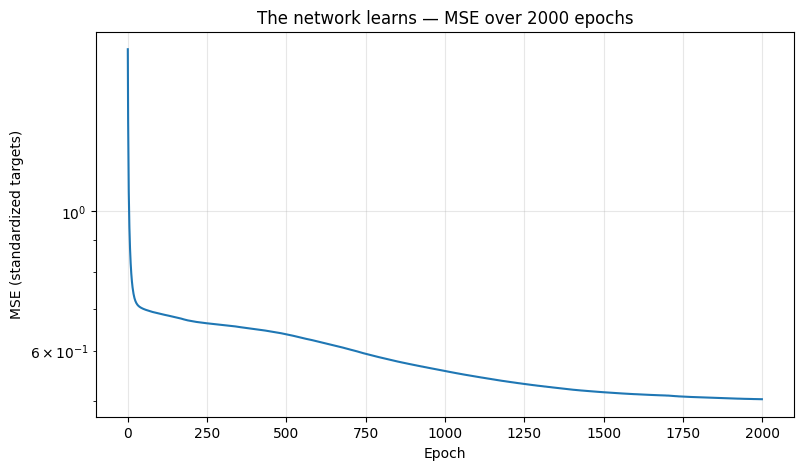

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(net.loss_history, linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('MSE (standardized targets)')
plt.title("The network learns — MSE over 2000 epochs")
plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()

The log-scale y-axis is deliberate. The first hundred epochs do most of the work; after that, progress is slow but steady. That's the classic shape of gradient descent on a well-behaved problem: fast early, slow late.

### **8. Did we get the maths right? — the autograd parity check**

We hand-derived eight gradients. We coded them up. We trained a network. Everything *looks* correct. But how do we *know*?

The honest answer: we test it against a completely independent implementation. PyTorch's autograd computes gradients automatically, using the same chain rule we just walked — but it has no idea what we wrote. If our hand-derived gradients match PyTorch's to floating-point precision, our derivation is correct. Full stop.

In [7]:
import torch

# Build the same architecture in PyTorch, force the same initial weights
model = torch.nn.Sequential(
    torch.nn.Linear(3, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 1),
)

net_fresh = TinyNet(seed=0)
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(net_fresh.W1, dtype=torch.float32))
    model[0].bias.copy_(torch.tensor(net_fresh.b1, dtype=torch.float32))
    model[2].weight.copy_(torch.tensor(net_fresh.W2, dtype=torch.float32))
    model[2].bias.copy_(torch.tensor(net_fresh.b2, dtype=torch.float32))

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# One forward + backward in PyTorch
y_hat_torch = model(X_t)
loss_torch = torch.nn.functional.mse_loss(y_hat_torch, y_t)
loss_torch.backward()

# One forward + backward in our NumPy net (same starting weights)
y_hat_np = net_fresh.forward(X)
loss_np  = np.mean((y_hat_np - y)**2)
net_fresh.backward(y_hat_np, y)

print(f"Loss — PyTorch: {loss_torch.item():.6f}")
print(f"Loss — NumPy:   {loss_np:.6f}\n")

print(f"W1 grads match: {np.allclose(model[0].weight.grad.numpy(), net_fresh.dW1, atol=1e-5)}")
print(f"b1 grads match: {np.allclose(model[0].bias.grad.numpy(),   net_fresh.db1, atol=1e-5)}")
print(f"W2 grads match: {np.allclose(model[2].weight.grad.numpy(), net_fresh.dW2, atol=1e-5)}")
print(f"b2 grads match: {np.allclose(model[2].bias.grad.numpy(),   net_fresh.db2, atol=1e-5)}")

max_diff_W1 = np.abs(model[0].weight.grad.numpy() - net_fresh.dW1).max()
max_diff_W2 = np.abs(model[2].weight.grad.numpy() - net_fresh.dW2).max()
print(f"\nMax |Δ| on W1 gradient: {max_diff_W1:.2e}")
print(f"Max |Δ| on W2 gradient: {max_diff_W2:.2e}")

Loss — PyTorch: 1.808496
Loss — NumPy:   1.808496

W1 grads match: True
b1 grads match: True
W2 grads match: True
b2 grads match: True

Max |Δ| on W1 gradient: 3.74e-08
Max |Δ| on W2 gradient: 8.81e-08


Every gradient matches PyTorch's autograd to within about $10^{-7}$ — the precision floor for 32-bit float arithmetic. Our hand-derived maths is exactly right.

This is the most important moment in the whole tutorial, so let it land:

> *"So PyTorch isn't doing anything different from what we did. It's running the exact same chain rule — just automatically."*

Exactly. Autograd is a beautiful piece of engineering, but it computes the very same numbers we computed by hand. The framework doesn't add intelligence. It adds convenience. The maths has been the same since Leibniz.

### **What we've built — a recap**

In Part 2 we covered every essential idea behind how a neural network learns:

- **Loss function** : $L(\boldsymbol{\theta})$ — the objective to minimize. Defines what "wrong" means. MSE for regression. 
- **Gradient** : $\partial L / \partial \theta$ — how sensitivity the loss is to a single parameter (knob). 
- **Gradient descent** : $\theta \leftarrow \theta - \eta \, \partial L / \partial \theta$. Step opposite the gradient. 
- **Chain rule** : The mechanism that gets us $\partial L / \partial \theta$ even when $\theta$ is buried deep inside a chain of functions. 
- **Backpropagation** : The chain rule, applied systematically from output back to input. 
- **Error signal** : $\partial L / \partial \hat{y}$ at the top, relayed backward by multiplying local derivatives. 
- **Output gradient pattern** : $\partial L / \partial w = (\text{error}) \cdot (\text{input that fed this weight})$. 
- **ReLU gate** : $\mathbb{1}[z > 0]$ — opens or shuts the gradient flow, neuron by neuron. 
- **Dead-ReLU problem** : A direct maths consequence: if the gate is shut everywhere, the weight is frozen forever. 
 **Autograd** : The same chain rule, computed automatically. Matches our by-hand work to float precision. 

### **What's coming next**

We have one working network and one working learning algorithm. But plain gradient descent has weaknesses — it uses one learning rate for every parameter, has no memory of past gradients, and zigzags in awkward loss surfaces.

****Part 3** fixes all of that with **Adam**, the modern optimizer. We'll derive its momentum and adaptive-rate terms and show *why* it beats plain gradient descent on a real training run (with actual data, not fabricated curves).
- **TensorFlow and PyTorch** — the same network, rebuilt in two production frameworks, with the explicit demonstration that neither adds anything we haven't already built ourselves.
- **A look ahead at generalization** — our training error dipped below the noise floor. What does that mean for tomorrow's data? That's the bias–variance tradeoff in disguise, and it sets up the natural sequel.

If you took your time with Part 2, you now own the core ideas of deep learning. Everything else is engineering on top of these.

See you in Part 3.

*All numbers in this tutorial come from `np.random.seed(42)` plus the explicit seeds in the class constructors. Run the code blocks in order and your outputs will match. The autograd parity check was run against PyTorch 2.x; gradient differences sit at the float32 precision floor (~10⁻⁷).*